In [7]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay, silhouette_score,
                             mean_absolute_error, mean_squared_error, r2_score)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
RANDOM = 42
np.random.seed(RANDOM)

## 1) EDA — Exploratory Data Analysis


In [8]:
df = pd.read_csv('/Churn Modeling.csv')
print('Shape:', df.shape)
display(df.head())
print()
df.info()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicated rows:', df.duplicated().sum())
print('Duplicated CustomerId:', df['CustomerId'].duplicated().sum())
display(df.describe().T.round(2))

Missing values: 0
Duplicated rows: 0
Duplicated CustomerId: 0


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
CustomerId,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
CreditScore,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48


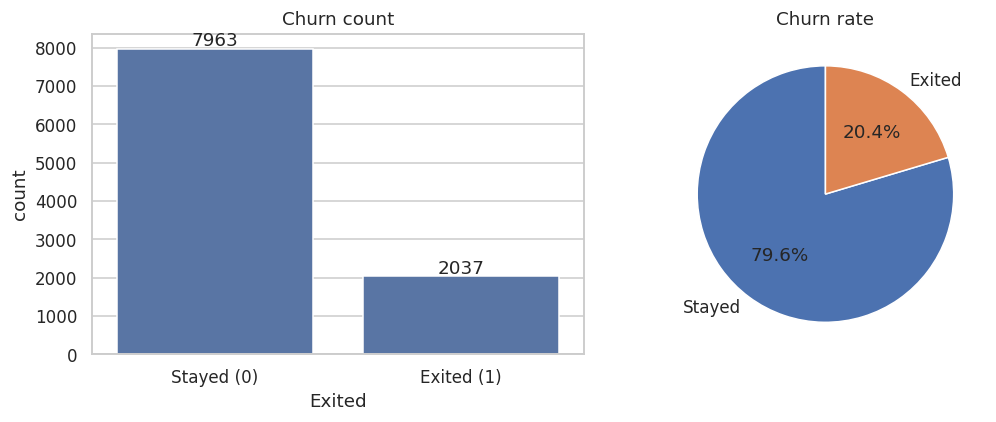

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
counts = df['Exited'].value_counts()
sns.countplot(x='Exited', data=df, ax=ax[0])
ax[0].set_title('Churn count'); ax[0].set_xticklabels(['Stayed (0)', 'Exited (1)'])
for i, v in enumerate(counts.sort_index()): ax[0].text(i, v + 80, f'{v}', ha='center')
ax[1].pie(counts.sort_index(), labels=['Stayed', 'Exited'], autopct='%1.1f%%', startangle=90)
ax[1].set_title('Churn rate')
plt.tight_layout(); plt.show()

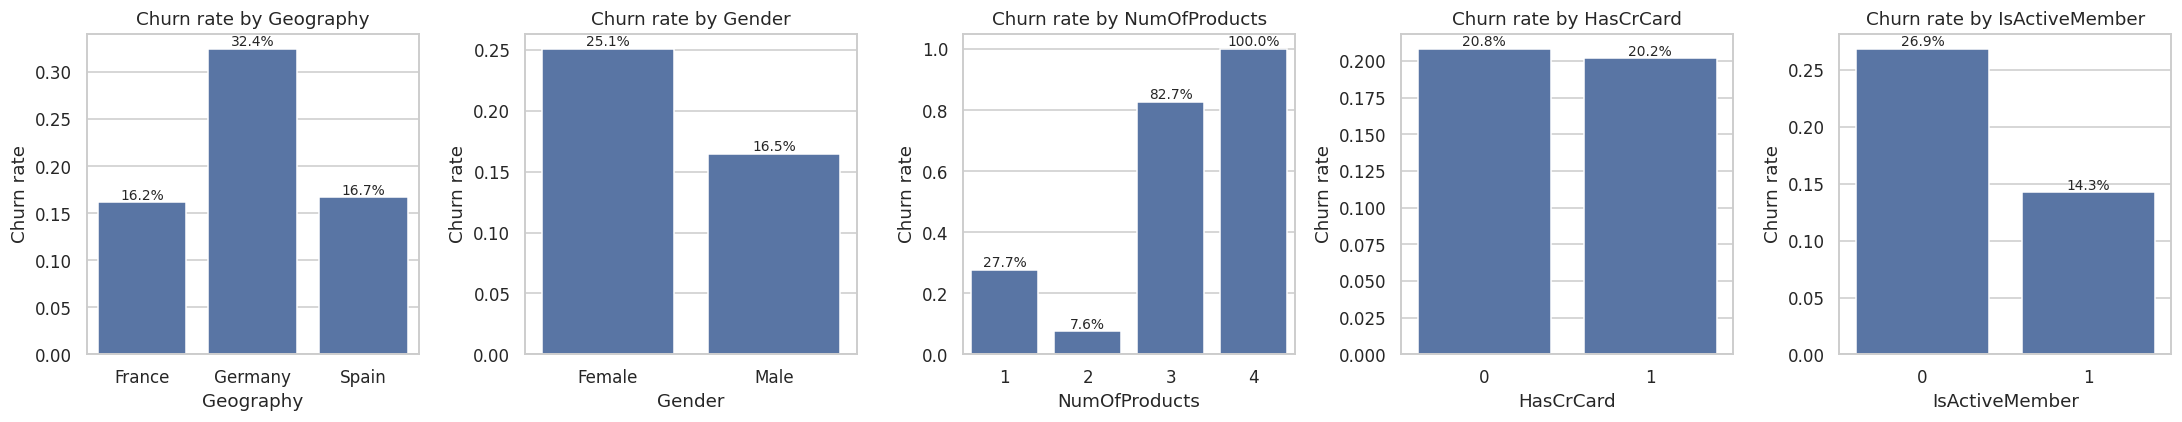

In [11]:
cat_cols = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, c in zip(axes, cat_cols):
    rate = df.groupby(c)['Exited'].mean().reset_index()
    sns.barplot(data=rate, x=c, y='Exited', ax=ax)
    ax.set_title(f'Churn rate by {c}'); ax.set_ylabel('Churn rate')
    for p in ax.patches: ax.annotate(f'{p.get_height():.1%}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

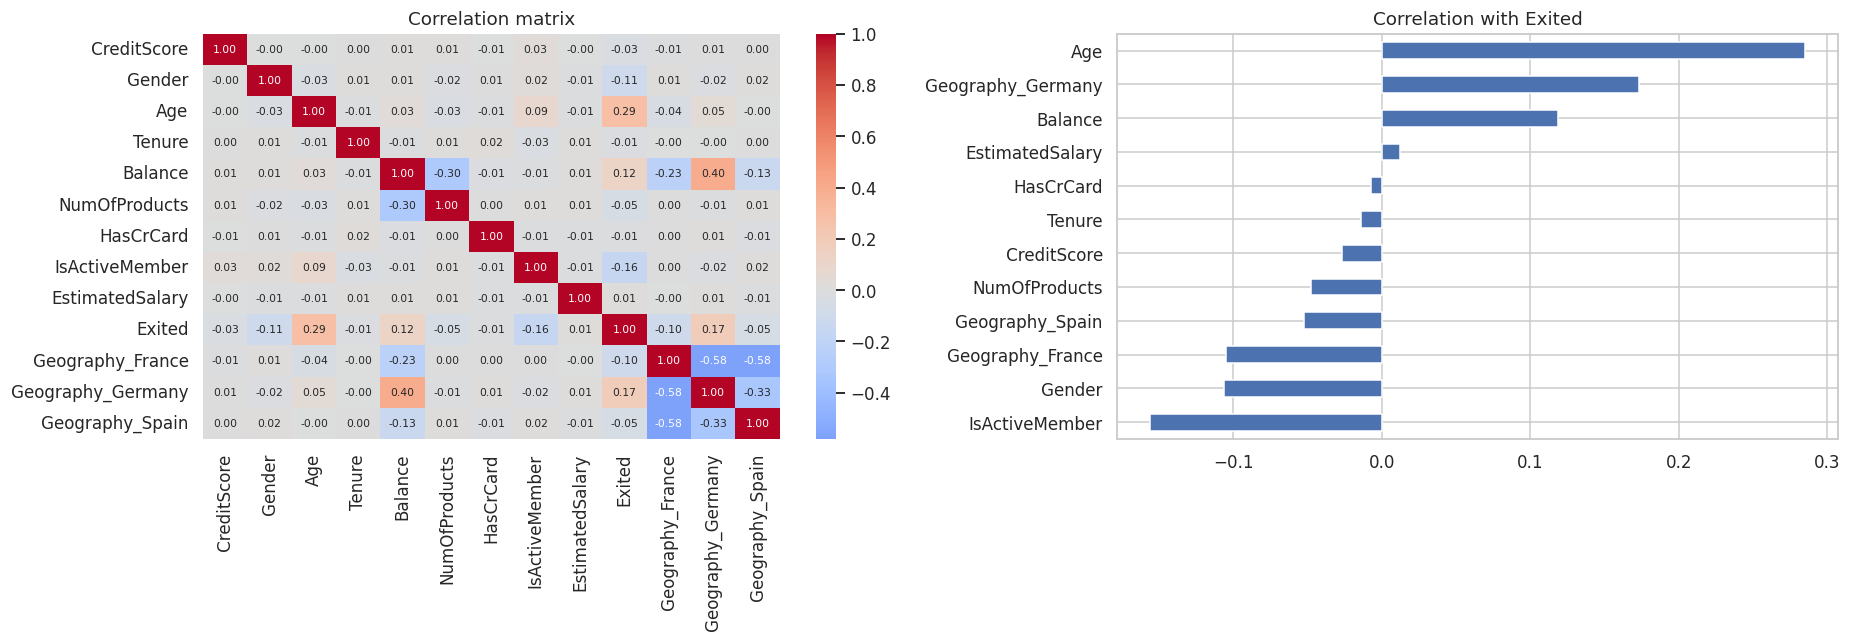

In [12]:
df_corr = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).copy()
df_corr['Gender'] = (df_corr['Gender'] == 'Male').astype(int)
df_corr = pd.get_dummies(df_corr, columns=['Geography'], dtype=int)

fig, ax = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[0], annot_kws={'size': 7})
ax[0].set_title('Correlation matrix')
df_corr.corr()['Exited'].drop('Exited').sort_values().plot.barh(ax=ax[1])
ax[1].set_title('Correlation with Exited')
plt.tight_layout(); plt.show()


## 2) Preprocessing


In [13]:
data = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).copy()
data['Gender'] = (data['Gender'] == 'Male').astype(int)          # Male=1, Female=0
data = pd.get_dummies(data, columns=['Geography'], drop_first=True, dtype=int)   # France = baseline

X = data.drop(columns='Exited')
y = data['Exited'].values
feature_names = X.columns.tolist()
print('Features:', feature_names)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM)
scaler = StandardScaler().fit(X_train)
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)
Xtr_raw, Xte_raw = X_train.values, X_test.values

print('Train:', Xtr_s.shape, ' Test:', Xte_s.shape)
print('Churn rate  train: %.3f | test: %.3f' % (y_train.mean(), y_test.mean()))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM)

Features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
Train: (8000, 11)  Test: (2000, 11)
Churn rate  train: 0.204 | test: 0.203



###  Logistic Regression



Model: Logistic Regression
AUC:           0.777
Accuracy:      0.714
Precision:     0.387
Recall:        0.700
F1-Score:      0.499


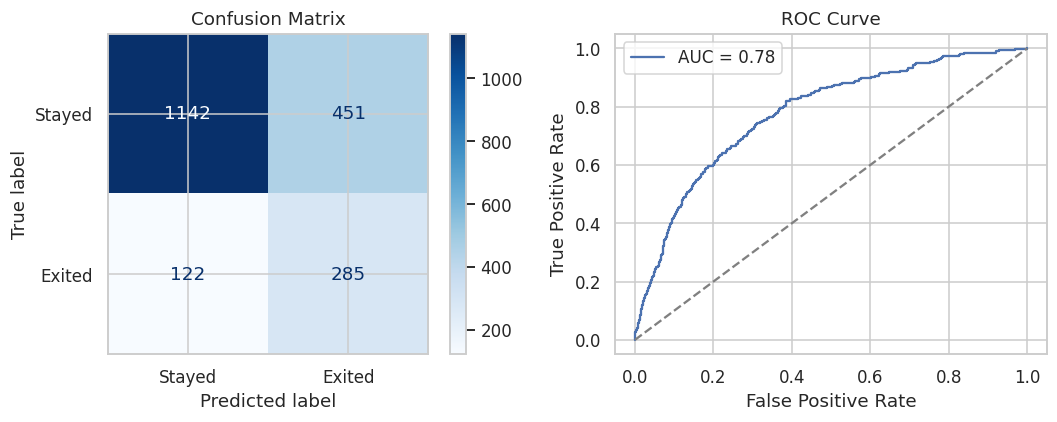

,feature,coef,odds_ratio
7,IsActiveMember,-0.442,0.642
1,Gender,-0.272,0.762
0,CreditScore,-0.087,0.917
5,NumOfProducts,-0.058,0.944
6,HasCrCard,-0.032,0.969
3,Tenure,-0.019,0.981
10,Geography_Spain,0.024,1.024
8,EstimatedSalary,0.051,1.052
4,Balance,0.176,1.192
9,Geography_Germany,0.358,1.430


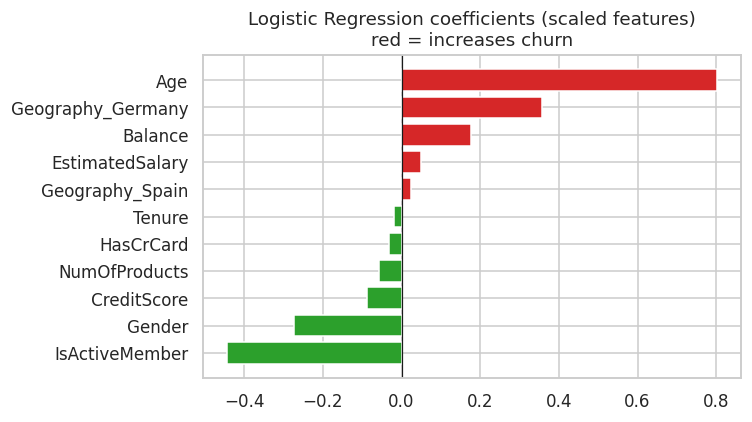

In [15]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f'\nModel: {name}')
    print('AUC:           %.3f' % roc_auc_score(y_true, y_proba))
    print('Accuracy:      %.3f' % accuracy_score(y_true, y_pred))
    print('Precision:     %.3f' % precision_score(y_true, y_pred))
    print('Recall:        %.3f' % recall_score(y_true, y_pred))
    print('F1-Score:      %.3f' % f1_score(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Exited'])
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    disp.plot(cmap='Blues', ax=ax[0]); ax[0].set_title('Confusion Matrix'); plt.grid(False)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_proba):.2f}')
    ax[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
    ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title('ROC Curve'); ax[1].legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

lr_model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM).fit(Xtr_s, y_train)
evaluate('Logistic Regression', y_test, lr_model.predict(Xte_s), lr_model.predict_proba(Xte_s)[:, 1])

coef = pd.DataFrame({'feature': feature_names, 'coef': lr_model.coef_[0]})
coef['odds_ratio'] = np.exp(coef['coef'])
coef = coef.sort_values('coef')
display(coef.round(3))
plt.figure(figsize=(7, 4)); plt.barh(coef['feature'], coef['coef'], color=np.where(coef['coef'] > 0, 'tab:red', 'tab:green'))
plt.axvline(0, color='k', lw=.8); plt.title('Logistic Regression coefficients (scaled features)\nred = increases churn'); plt.tight_layout(); plt.show()


Model: SVM (Linear)
AUC:           0.778
Accuracy:      0.721
Precision:     0.396
Recall:        0.708
F1-Score:      0.508


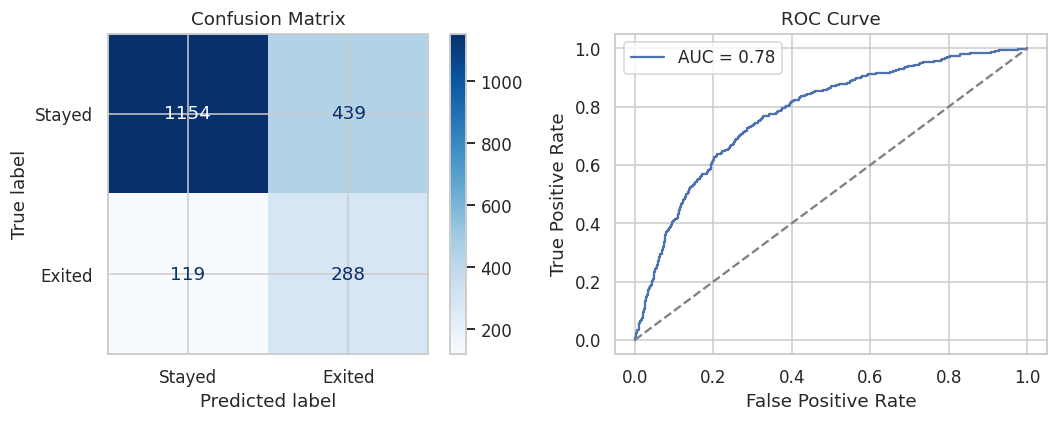

Best RBF params: {'C': 0.5}  CV AUC = 0.848

Model: SVM (RBF)
AUC:           0.853
Accuracy:      0.784
Precision:     0.481
Recall:        0.737
F1-Score:      0.582


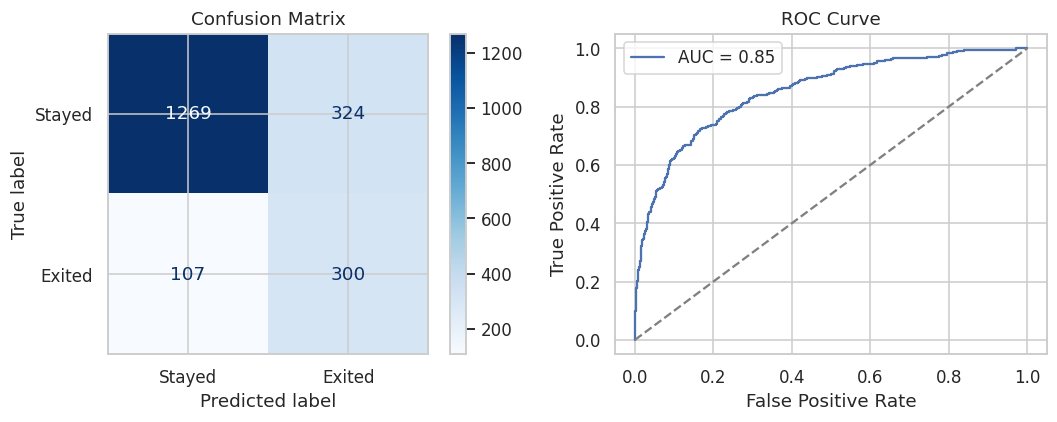

Number of support vectors: 4482 of 8000


In [16]:
svm_lin = SVC(kernel='linear', class_weight='balanced', C=1.0).fit(Xtr_s, y_train)
evaluate('SVM (Linear)', y_test, svm_lin.predict(Xte_s), svm_lin.decision_function(Xte_s))

grid = GridSearchCV(SVC(kernel='rbf', class_weight='balanced', gamma='scale'),
                    {'C': [0.5, 1, 3, 10]}, cv=3, scoring='roc_auc', n_jobs=-1).fit(Xtr_s, y_train)
print('Best RBF params:', grid.best_params_, ' CV AUC = %.3f' % grid.best_score_)
svm = grid.best_estimator_
evaluate('SVM (RBF)', y_test, svm.predict(Xte_s), svm.decision_function(Xte_s))
print('Number of support vectors:', svm.n_support_.sum(), 'of', len(y_train))



###  Decision Tree


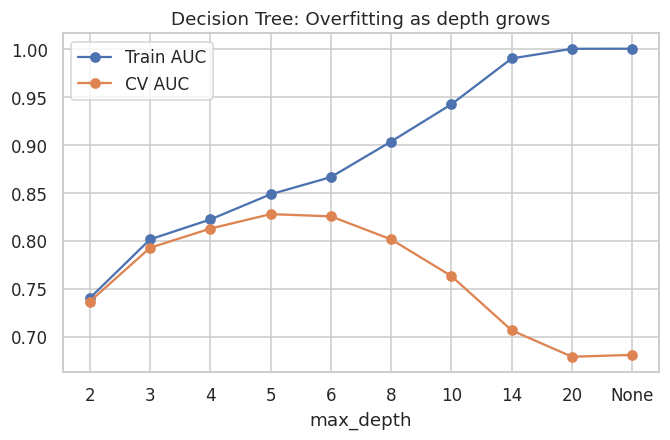

Best max_depth = 5

Model: Decision Tree
AUC:           0.838
Accuracy:      0.770
Precision:     0.461
Recall:        0.764
F1-Score:      0.575


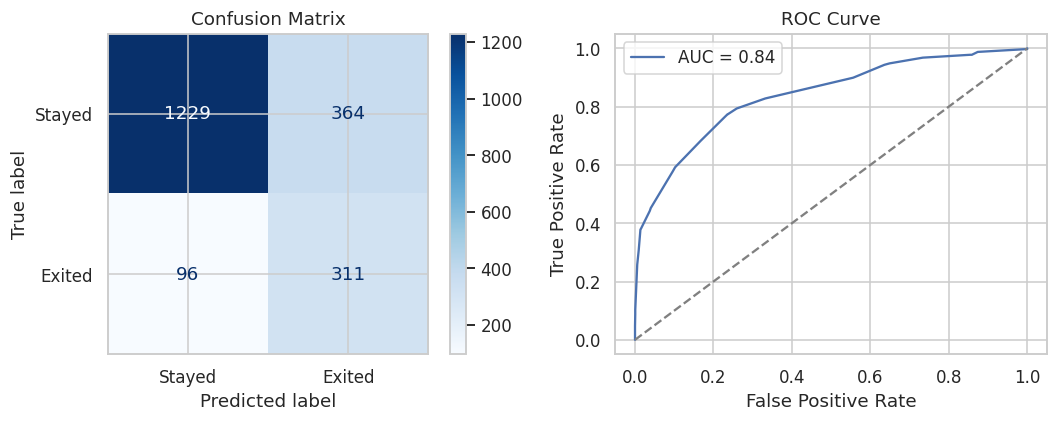

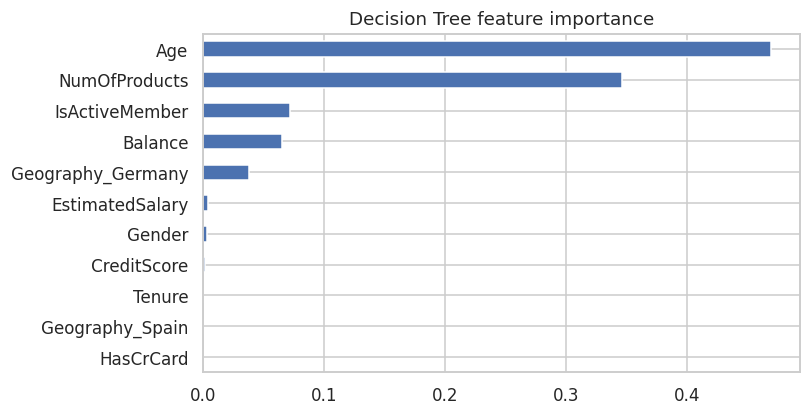

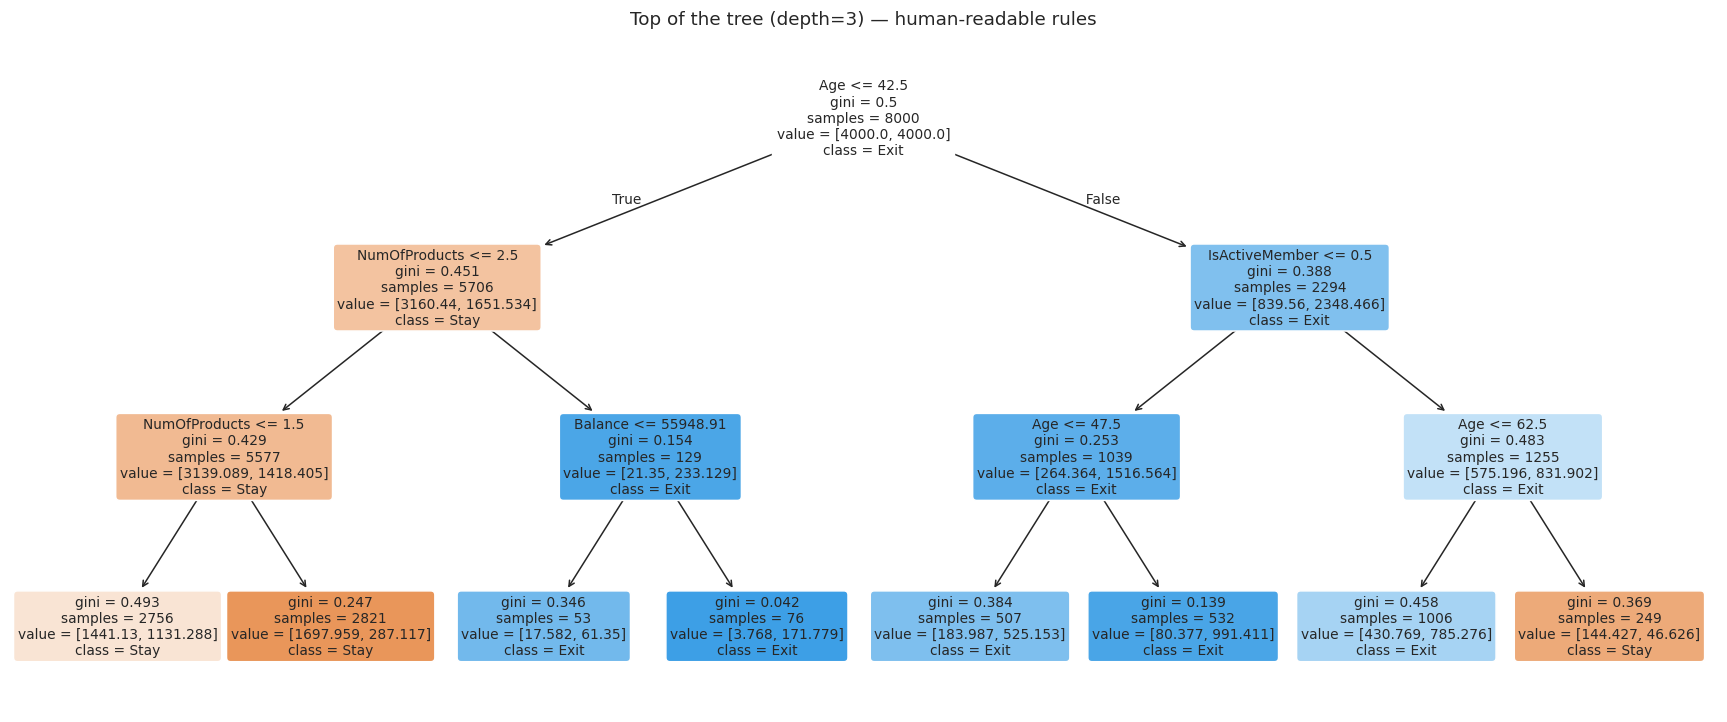

In [17]:
depths = [2, 3, 4, 5, 6, 8, 10, 14, 20, None]
tr_sc, cv_sc = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=RANDOM)
    tr_sc.append(roc_auc_score(y_train, m.fit(Xtr_raw, y_train).predict_proba(Xtr_raw)[:, 1]))
    cv_sc.append(cross_val_score(m, Xtr_raw, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean())
lbl = [str(d) for d in depths]
plt.figure(figsize=(7, 4)); plt.plot(lbl, tr_sc, marker='o', label='Train AUC'); plt.plot(lbl, cv_sc, marker='o', label='CV AUC')
plt.title('Decision Tree: Overfitting as depth grows'); plt.xlabel('max_depth'); plt.legend(); plt.show()

best_d = depths[int(np.argmax(cv_sc))]; print('Best max_depth =', best_d)
dt = DecisionTreeClassifier(max_depth=best_d, class_weight='balanced', random_state=RANDOM).fit(Xtr_raw, y_train)
evaluate('Decision Tree', y_test, dt.predict(Xte_raw), dt.predict_proba(Xte_raw)[:, 1])

fi = pd.Series(dt.feature_importances_, index=feature_names).sort_values()
fi.plot.barh(figsize=(7, 4), title='Decision Tree feature importance'); plt.show()

plt.figure(figsize=(20, 8))
plot_tree(DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=RANDOM).fit(Xtr_raw, y_train),
          feature_names=feature_names, class_names=['Stay', 'Exit'], filled=True, rounded=True, fontsize=9)
plt.title('Top of the tree (depth=3) — human-readable rules'); plt.show()


Model: Naive Bayes
AUC:           0.746
Accuracy:      0.786
Precision:     0.361
Recall:        0.064
F1-Score:      0.109


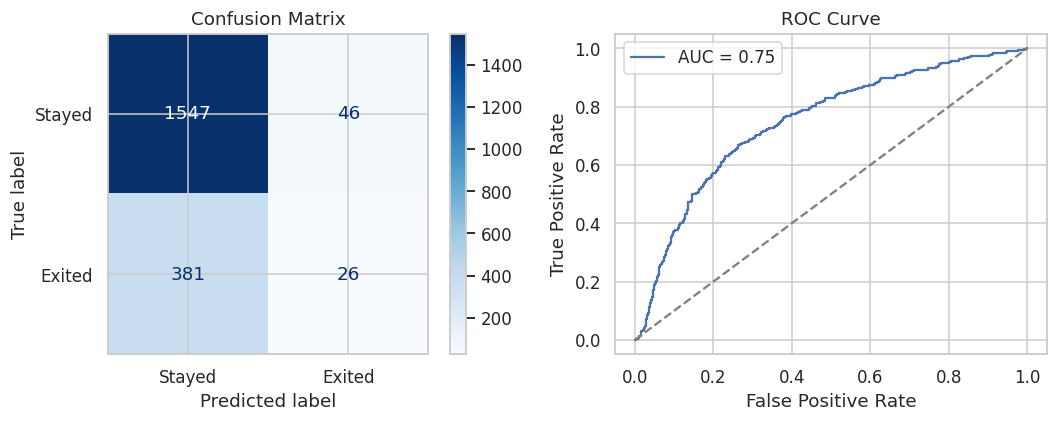


Strongest pairwise correlations between features (independence assumption is violated):
Balance            Geography_Germany    0.400
Geography_Germany  Geography_Spain      0.334
Balance            NumOfProducts        0.308
                   Geography_Spain      0.131
dtype: float64


In [18]:
nb_model = GaussianNB().fit(Xtr_raw, y_train)
evaluate('Naive Bayes', y_test, nb_model.predict(Xte_raw), nb_model.predict_proba(Xte_raw)[:, 1])

# Why "naive"? check feature dependence
print('\nStrongest pairwise correlations between features (independence assumption is violated):')
cm_ = X_train.corr().abs().where(np.triu(np.ones((X.shape[1],)*2), 1).astype(bool)).stack().sort_values(ascending=False).head(4)
print(cm_.round(3))

### Random Forest

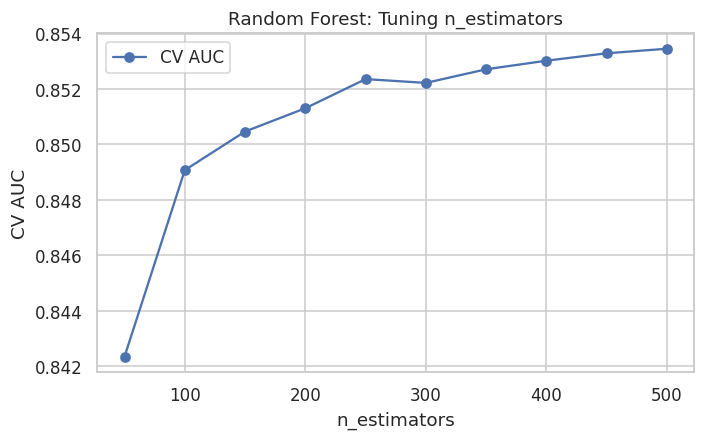

Best n_estimators = 500

Model: Random Forest
AUC:           0.857
Accuracy:      0.865
Precision:     0.797
Recall:        0.452
F1-Score:      0.577


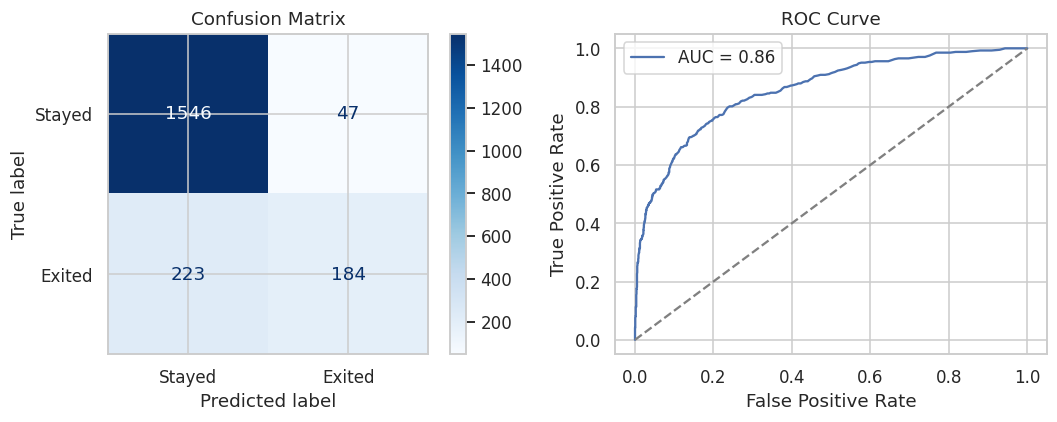

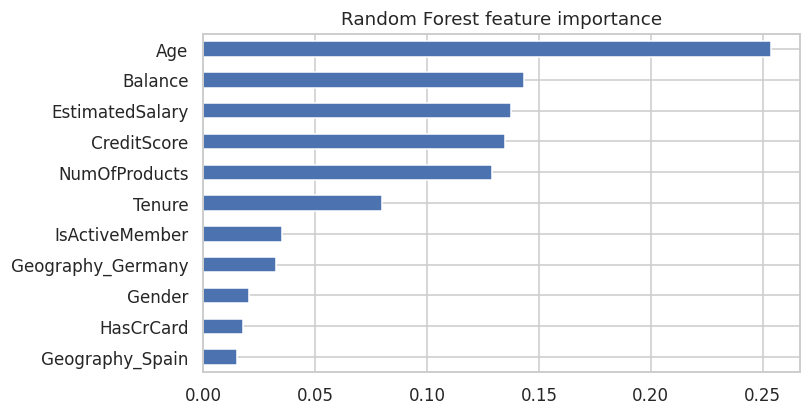

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Find the best number of estimators
scores = []
estimators_range = range(50, 501, 50)
for n_estimators in estimators_range:
    rf_model = RandomForestClassifier(n_estimators=n_estimators, class_weight='balanced', random_state=RANDOM, n_jobs=-1)
    scores.append(cross_val_score(rf_model, Xtr_raw, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean())

plt.figure(figsize=(7, 4)); plt.plot(list(estimators_range), scores, marker='o', label='CV AUC')
plt.title('Random Forest: Tuning n_estimators'); plt.xlabel('n_estimators'); plt.ylabel('CV AUC'); plt.legend(); plt.show()

best_n_estimators = estimators_range[np.argmax(scores)]
print(f'Best n_estimators = {best_n_estimators}')

rf_model = RandomForestClassifier(n_estimators=best_n_estimators, class_weight='balanced', random_state=RANDOM, n_jobs=-1).fit(Xtr_raw, y_train)
evaluate('Random Forest', y_test, rf_model.predict(Xte_raw), rf_model.predict_proba(Xte_raw)[:, 1])

fi = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values()
fi.plot.barh(figsize=(7, 4), title='Random Forest feature importance'); plt.show()


Model Comparison:


,AUC,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.777,0.714,0.387,0.700,0.499
SVM (Linear),0.778,0.721,0.396,0.708,0.508
SVM (RBF),0.853,0.784,0.481,0.737,0.582
Decision Tree,0.838,0.770,0.461,0.764,0.575
Naive Bayes,0.746,0.786,0.361,0.064,0.109
Random Forest,0.857,0.865,0.797,0.452,0.577


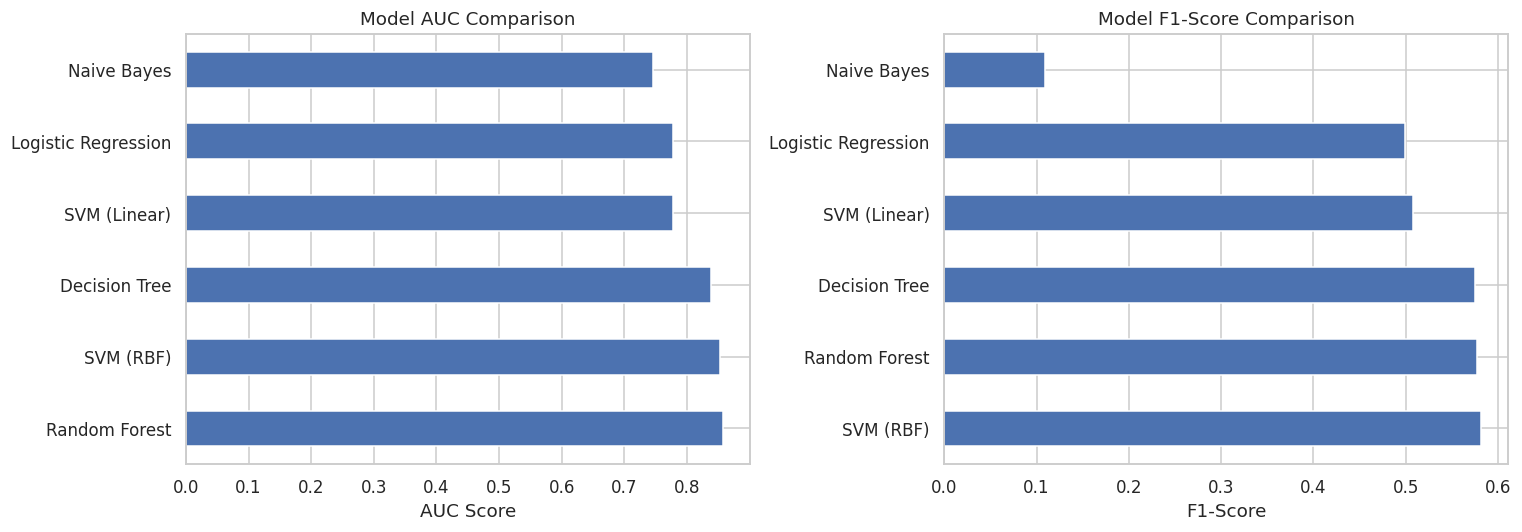

In [22]:
model_metrics = {
    'Logistic Regression': {'AUC': 0.777, 'Accuracy': 0.714, 'Precision': 0.387, 'Recall': 0.700, 'F1-Score': 0.499},
    'SVM (Linear)': {'AUC': 0.778, 'Accuracy': 0.721, 'Precision': 0.396, 'Recall': 0.708, 'F1-Score': 0.508},
    'SVM (RBF)': {'AUC': 0.853, 'Accuracy': 0.784, 'Precision': 0.481, 'Recall': 0.737, 'F1-Score': 0.582},
    'Decision Tree': {'AUC': 0.838, 'Accuracy': 0.770, 'Precision': 0.461, 'Recall': 0.764, 'F1-Score': 0.575},
    'Naive Bayes': {'AUC': 0.746, 'Accuracy': 0.786, 'Precision': 0.361, 'Recall': 0.064, 'F1-Score': 0.109},
    'Random Forest': {'AUC': 0.857, 'Accuracy': 0.865, 'Precision': 0.797, 'Recall': 0.452, 'F1-Score': 0.577}
}

metrics_df = pd.DataFrame.from_dict(model_metrics, orient='index')
print("\nModel Comparison:")
display(metrics_df.round(3))

# Plotting AUC and F1-Score for comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
metrics_df[['AUC']].sort_values(by='AUC', ascending=False).plot(kind='barh', ax=ax[0], legend=False)
ax[0].set_title('Model AUC Comparison')
ax[0].set_xlabel('AUC Score')

metrics_df[['F1-Score']].sort_values(by='F1-Score', ascending=False).plot(kind='barh', ax=ax[1], legend=False)
ax[1].set_title('Model F1-Score Comparison')
ax[1].set_xlabel('F1-Score')

plt.tight_layout()
plt.show()